# 📈 Module 3: Distributions — Real-Life Cases

**The Story:** PizzaChain's data team needs to understand the SHAPE of their data before choosing models or setting alerts.
- Are delivery times bell-shaped or lopsided?
- How many support calls should we expect per hour?
- Out of 100 promo emails, how many will convert?

Each question maps to a different distribution. Let's see which one fits where.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

---
## Case 1: Normal Distribution — "Are our order values bell-shaped?"

**When to use:** Continuous data that clusters around an average with symmetric tails (heights, test scores, order values).

**Parameters:** μ (mean), σ (std dev)

**Why it matters:** Many statistical tests ASSUME normality. If your data isn't normal, those tests give wrong answers.

In [2]:
order_values = np.round(np.random.normal(22, 5, 1000), 2)
mu = order_values.mean()
sigma = order_values.std()

print('📊 DATA SUMMARY')
print(f'  Mean (μ)   = ${mu:.2f}')
print(f'  Std Dev (σ)= ${sigma:.2f}')
print(f'  Skewness   = {pd.Series(order_values).skew():.3f} (close to 0 = symmetric ✅)')
print()

# Check 68-95-99.7 rule
within_1sd = np.mean((order_values >= mu - sigma) & (order_values <= mu + sigma)) * 100
within_2sd = np.mean((order_values >= mu - 2*sigma) & (order_values <= mu + 2*sigma)) * 100
within_3sd = np.mean((order_values >= mu - 3*sigma) & (order_values <= mu + 3*sigma)) * 100

print('📏 68-95-99.7 RULE CHECK')
print(f'  Within ±1σ (${mu-sigma:.0f}–${mu+sigma:.0f}): {within_1sd:.1f}% (theory: 68%)')
print(f'  Within ±2σ (${mu-2*sigma:.0f}–${mu+2*sigma:.0f}): {within_2sd:.1f}% (theory: 95%)')
print(f'  Within ±3σ (${mu-3*sigma:.0f}–${mu+3*sigma:.0f}): {within_3sd:.1f}% (theory: 99.7%)')
print()
print('💡 INFERENCE: Order values follow a near-perfect bell curve.')
print('   We can safely use mean/std dev to describe this data.')
print('   Any order above ${:.0f} (μ+3σ) is an outlier worth investigating.'.format(mu + 3*sigma))

📊 DATA SUMMARY
  Mean (μ)   = $22.10
  Std Dev (σ)= $4.89
  Skewness   = 0.117 (close to 0 = symmetric ✅)

📏 68-95-99.7 RULE CHECK
  Within ±1σ ($17–$27): 68.6% (theory: 68%)
  Within ±2σ ($12–$32): 95.6% (theory: 95%)
  Within ±3σ ($7–$37): 99.7% (theory: 99.7%)

💡 INFERENCE: Order values follow a near-perfect bell curve.
   We can safely use mean/std dev to describe this data.
   Any order above $37 (μ+3σ) is an outlier worth investigating.


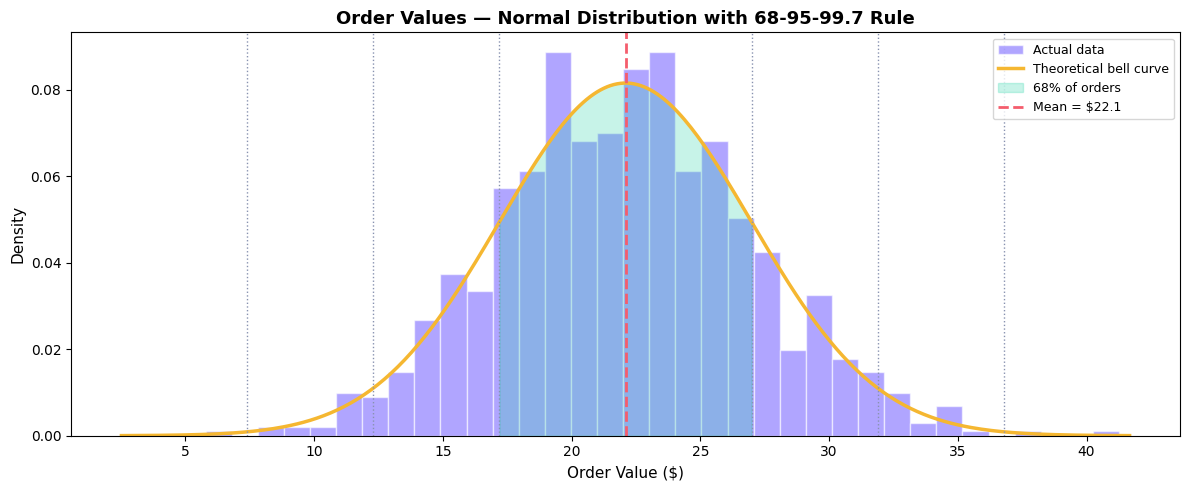

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram
ax.hist(order_values, bins=35, density=True, color='#7c6aff', alpha=0.6, edgecolor='white', label='Actual data')

# Theoretical bell curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#f5b731', linewidth=2.5, label='Theoretical bell curve')

# Shade 68% band
x_fill = np.linspace(mu - sigma, mu + sigma, 100)
ax.fill_between(x_fill, stats.norm.pdf(x_fill, mu, sigma), color='#22d3a7', alpha=0.25, label='68% of orders')

# Mark mean and sigma boundaries
ax.axvline(mu, color='#f45d6d', linewidth=2, linestyle='--', label=f'Mean = ${mu:.1f}')
for mult, lbl in [(1, '±1σ'), (2, '±2σ'), (3, '±3σ')]:
    ax.axvline(mu + mult*sigma, color='#8892b0', linewidth=1, linestyle=':')
    ax.axvline(mu - mult*sigma, color='#8892b0', linewidth=1, linestyle=':')

ax.set_xlabel('Order Value ($)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Order Values — Normal Distribution with 68-95-99.7 Rule', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Case 2: Skewed Distribution — "Why delivery times DON'T follow a bell curve"

**When to use:** Data with a natural floor/ceiling that creates a long tail (delivery times, income, wait times).

**Why it matters:** If you use mean/std dev on skewed data, you'll get misleading results. Use median/IQR instead.

In [4]:
delivery_times = np.round(np.random.exponential(20, 1000) + 12, 1)

print('📊 DATA SUMMARY')
print(f'  Mean   = {delivery_times.mean():.1f} min')
print(f'  Median = {np.median(delivery_times):.1f} min')
print(f'  Std Dev= {delivery_times.std():.1f} min')
print(f'  Skew   = {pd.Series(delivery_times).skew():.2f} (> 0.5 = right-skewed ⚠️)')
print(f'  Min    = {delivery_times.min():.1f}, Max = {delivery_times.max():.1f}')
print()
print(f'💡 INFERENCE:')
print(f'   Mean ({delivery_times.mean():.0f} min) > Median ({np.median(delivery_times):.0f} min) → right-skewed.')
print(f'   A few very slow deliveries pull the mean up.')
print(f'   The MEDIAN better represents a "typical" delivery.')
print(f'   ACTION: Report median delivery time to customers, not mean.')

📊 DATA SUMMARY
  Mean   = 32.2 min
  Median = 26.5 min
  Std Dev= 20.0 min
  Skew   = 1.98 (> 0.5 = right-skewed ⚠️)
  Min    = 12.1, Max = 160.8

💡 INFERENCE:
   Mean (32 min) > Median (26 min) → right-skewed.
   A few very slow deliveries pull the mean up.
   The MEDIAN better represents a "typical" delivery.
   ACTION: Report median delivery time to customers, not mean.


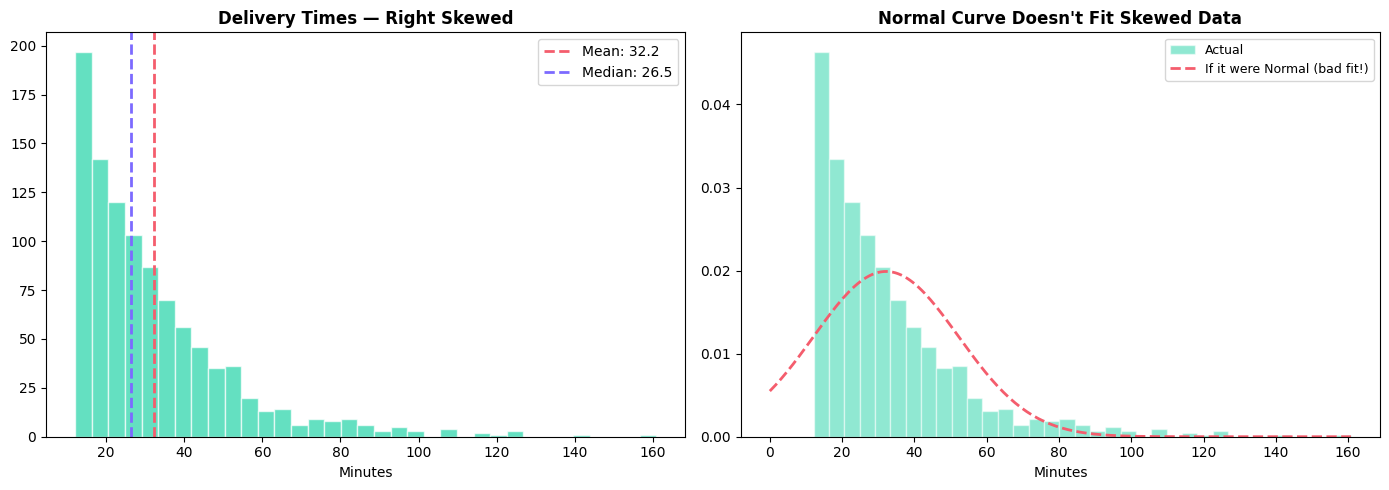

💡 The red dashed curve (Normal) clearly doesn't match the actual data.
   Using Normal-based tools on this data would give WRONG results.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with mean vs median
axes[0].hist(delivery_times, bins=35, color='#22d3a7', alpha=0.7, edgecolor='white')
axes[0].axvline(delivery_times.mean(), color='#f45d6d', linewidth=2, linestyle='--', label=f'Mean: {delivery_times.mean():.1f}')
axes[0].axvline(np.median(delivery_times), color='#7c6aff', linewidth=2, linestyle='--', label=f'Median: {np.median(delivery_times):.1f}')
axes[0].set_title('Delivery Times — Right Skewed', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].legend()

# Right: compare with a normal curve overlay to show the mismatch
axes[1].hist(delivery_times, bins=35, density=True, color='#22d3a7', alpha=0.5, edgecolor='white', label='Actual')
x_norm = np.linspace(0, delivery_times.max(), 200)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, delivery_times.mean(), delivery_times.std()),
             color='#f45d6d', linewidth=2, linestyle='--', label='If it were Normal (bad fit!)')
axes[1].set_title('Normal Curve Doesn\'t Fit Skewed Data', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Minutes')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('💡 The red dashed curve (Normal) clearly doesn\'t match the actual data.')
print('   Using Normal-based tools on this data would give WRONG results.')

---
## Case 3: Poisson Distribution — "How many support calls per hour?"

**When to use:** Counting events in a fixed time/space interval (calls/hour, errors/day, goals/match).

**Parameter:** λ (lambda) = average rate of events

**Key property:** Mean = Variance = λ

In [6]:
# Simulate 500 hours of support calls
lam = 6  # average 6 calls per hour
calls_per_hour = np.random.poisson(lam, 500)

print('📊 DATA SUMMARY')
print(f'  λ (expected avg)  = {lam} calls/hour')
print(f'  Observed mean     = {calls_per_hour.mean():.2f}')
print(f'  Observed variance = {calls_per_hour.var():.2f}')
print(f'  Mean ≈ Variance?  {"✅ Yes" if abs(calls_per_hour.mean() - calls_per_hour.var()) < 1 else "❌ No"} → confirms Poisson')
print()

# Probability calculations
p_zero = stats.poisson.pmf(0, lam)
p_10plus = 1 - stats.poisson.cdf(9, lam)

print('📊 PROBABILITY MATH')
print(f'  P(0 calls in an hour)  = {p_zero:.4f} = {p_zero*100:.2f}%')
print(f'  P(10+ calls in an hour)= {p_10plus:.4f} = {p_10plus*100:.1f}%')
print()
print(f'💡 INFERENCE:')
print(f'   Staff for ~{lam} calls/hour normally.')
print(f'   If you see 12+ calls in one hour, that\'s unusual — check if something broke.')
print(f'   P(12+) = {1-stats.poisson.cdf(11, lam):.3f} = {(1-stats.poisson.cdf(11, lam))*100:.1f}% — rare enough to investigate.')

📊 DATA SUMMARY
  λ (expected avg)  = 6 calls/hour
  Observed mean     = 5.91
  Observed variance = 5.53
  Mean ≈ Variance?  ✅ Yes → confirms Poisson

📊 PROBABILITY MATH
  P(0 calls in an hour)  = 0.0025 = 0.25%
  P(10+ calls in an hour)= 0.0839 = 8.4%

💡 INFERENCE:
   Staff for ~6 calls/hour normally.
   If you see 12+ calls in one hour, that's unusual — check if something broke.
   P(12+) = 0.020 = 2.0% — rare enough to investigate.


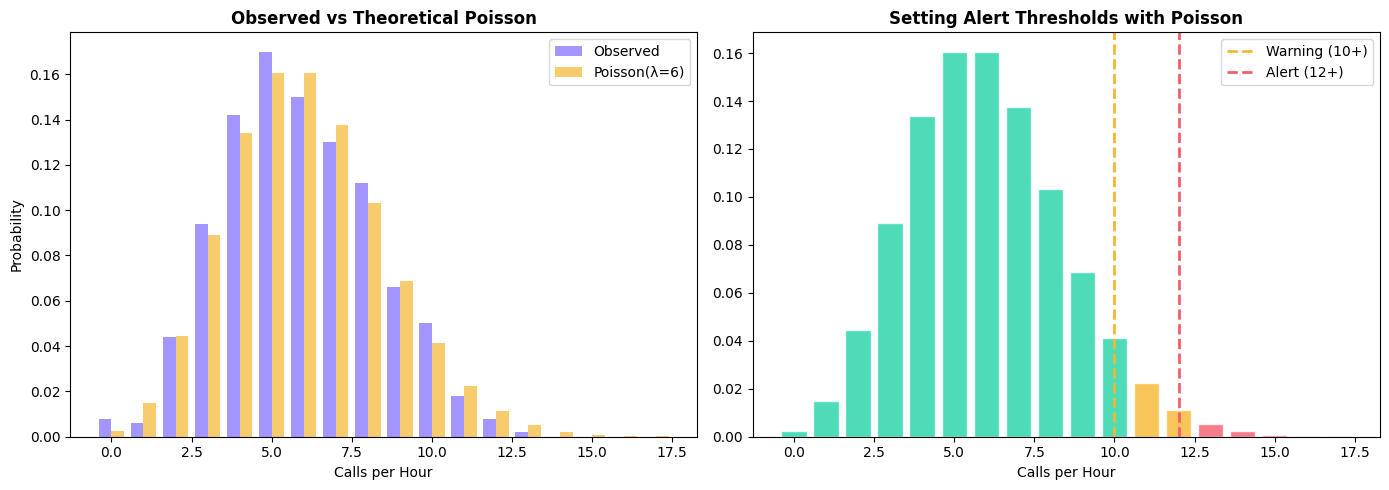

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual histogram vs theoretical Poisson
x_vals = np.arange(0, 18)
axes[0].bar(x_vals - 0.2, [np.mean(calls_per_hour == k) for k in x_vals], width=0.4,
            color='#7c6aff', alpha=0.7, label='Observed')
axes[0].bar(x_vals + 0.2, stats.poisson.pmf(x_vals, lam), width=0.4,
            color='#f5b731', alpha=0.7, label=f'Poisson(λ={lam})')
axes[0].set_xlabel('Calls per Hour')
axes[0].set_ylabel('Probability')
axes[0].set_title('Observed vs Theoretical Poisson', fontsize=12, fontweight='bold')
axes[0].legend()

# Right: alert threshold
colors = ['#22d3a7' if k <= 10 else '#f5b731' if k <= 12 else '#f45d6d' for k in x_vals]
axes[1].bar(x_vals, stats.poisson.pmf(x_vals, lam), color=colors, alpha=0.8, edgecolor='white')
axes[1].axvline(10, color='#f5b731', linewidth=2, linestyle='--', label='Warning (10+)')
axes[1].axvline(12, color='#f45d6d', linewidth=2, linestyle='--', label='Alert (12+)')
axes[1].set_xlabel('Calls per Hour')
axes[1].set_title('Setting Alert Thresholds with Poisson', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Case 4: Binomial Distribution — "Out of 100 promo emails, how many convert?"

**When to use:** Fixed number of trials (n), each with same success probability (p).

**Parameters:** n (trials), p (success rate per trial)

**Expected value:** n × p

In [8]:
n_emails = 100
p_convert = 0.12  # 12% conversion rate

# Simulate 500 campaigns
conversions = np.random.binomial(n_emails, p_convert, 500)
expected = n_emails * p_convert
std_binom = np.sqrt(n_emails * p_convert * (1 - p_convert))

print('📊 STEP-BY-STEP MATH')
print(f'  n = {n_emails} emails per campaign')
print(f'  p = {p_convert} (12% conversion rate)')
print(f'  Expected conversions = n × p = {n_emails} × {p_convert} = {expected}')
print(f'  Std Dev = √(n × p × (1-p)) = √({n_emails}×{p_convert}×{1-p_convert}) = {std_binom:.2f}')
print(f'  Normal range: {expected - 2*std_binom:.0f} to {expected + 2*std_binom:.0f} conversions (95%)')
print()
print(f'💡 INFERENCE:')
print(f'   Expect ~{expected:.0f} conversions per 100 emails, but anywhere from')
print(f'   {expected - 2*std_binom:.0f} to {expected + 2*std_binom:.0f} is normal variation.')
print(f'   If a campaign gets {expected + 3*std_binom:.0f}+ conversions, something worked unusually well — investigate what!')
print(f'   If a campaign gets {max(0, expected - 3*std_binom):.0f} or fewer, something went wrong.')

📊 STEP-BY-STEP MATH
  n = 100 emails per campaign
  p = 0.12 (12% conversion rate)
  Expected conversions = n × p = 100 × 0.12 = 12.0
  Std Dev = √(n × p × (1-p)) = √(100×0.12×0.88) = 3.25
  Normal range: 6 to 18 conversions (95%)

💡 INFERENCE:
   Expect ~12 conversions per 100 emails, but anywhere from
   6 to 18 is normal variation.
   If a campaign gets 22+ conversions, something worked unusually well — investigate what!
   If a campaign gets 2 or fewer, something went wrong.


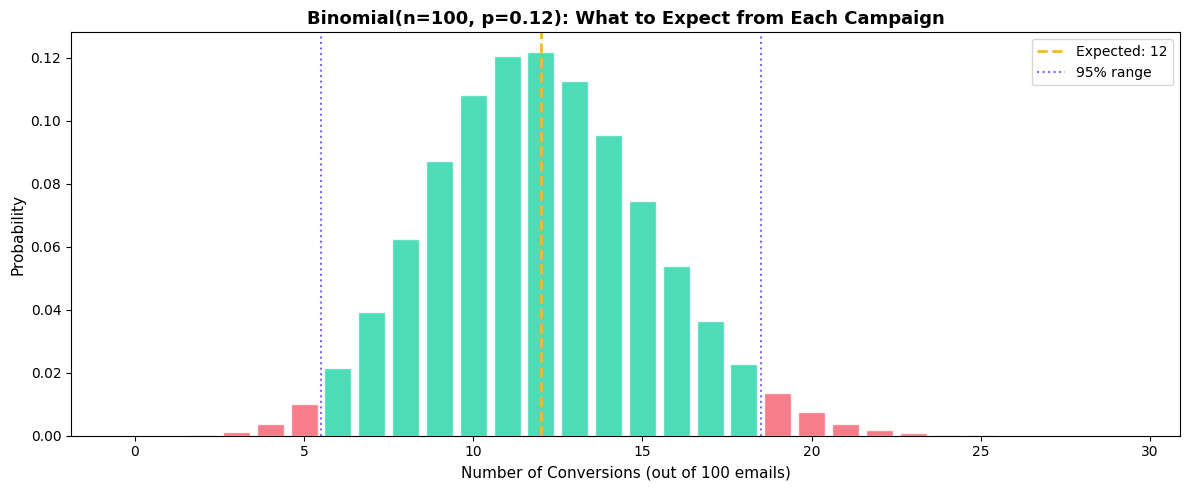

💡 Green bars = normal range. Red bars = unusually high or low — worth investigating.


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

x_vals = np.arange(0, 30)
probs = stats.binom.pmf(x_vals, n_emails, p_convert)
colors = ['#22d3a7' if expected - 2*std_binom <= k <= expected + 2*std_binom else '#f45d6d' for k in x_vals]

ax.bar(x_vals, probs, color=colors, alpha=0.8, edgecolor='white')
ax.axvline(expected, color='#f5b731', linewidth=2, linestyle='--', label=f'Expected: {expected:.0f}')
ax.axvline(expected - 2*std_binom, color='#7c6aff', linewidth=1.5, linestyle=':', label=f'95% range')
ax.axvline(expected + 2*std_binom, color='#7c6aff', linewidth=1.5, linestyle=':')

ax.set_xlabel('Number of Conversions (out of 100 emails)', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title(f'Binomial(n={n_emails}, p={p_convert}): What to Expect from Each Campaign', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('💡 Green bars = normal range. Red bars = unusually high or low — worth investigating.')

---
## 📝 Summary

| Case | Distribution | Data Shape | When to Use | Key Insight |
|---|---|---|---|---|
| Order values | Normal | Bell curve | Continuous, symmetric data | 68-95-99.7 rule works |
| Delivery times | Skewed | Long right tail | Data with a floor + rare extremes | Use median, not mean |
| Support calls | Poisson | Count data | Events per time period | Mean ≈ Variance confirms Poisson |
| Email conversions | Binomial | Success counts | Fixed trials, same probability | Expected = n × p |